# SISTEM INFORMASI GEOGRAFIS (SIG) - KLASIFIKASI TUTUPAN LAHAN (LULC)
### Ujian Tengah Semester (UTS): Analisis Spasial Penggunaan Lahan dan Kebijakan Publik
* **Wilayah Kajian:** Provinsi Jawa Timur
* **Metode:** Algoritma *Decision Tree Classifier* & Citra Satelit *Sentinel-2A Multispectral Instrument (MSI)*
* **Target Klasifikasi:** 6 Kelas (Sawah, Bangunan, Danau/Ranu, Lahan Hijau, Perairan Laut, Mangrove)
* **Jumlah Sampel:** Masing-masing 50 Titik Sampel (Total = 300 Titik Sampel)
* **Visualisasi Spasial:** Web Map Folium dengan Layer WMS / XYZ Tile Google Maps Satellite Hybrid

---

## 1. Data Understanding

### 1.1 Tujuan Analisis Land Use & Land Cover (LULC) dalam Konteks Kebijakan & SIG
Pemetaan tutupan lahan (*Land Cover*) dan penggunaan lahan (*Land Use*) berbasis analisis spasial di Provinsi Jawa Timur memiliki keterkaitan langsung dengan instrumen hukum dan kebijakan pembangunan daerah:

1. **Perlindungan Lahan Pertanian Pangan Berkelanjutan (LP2B):**
   * Mengacu pada **UU No. 41 Tahun 2009**, analisis spasial kelas *Sawah* berfungsi memonitor laju alih fungsi lahan sawah beririgasi teknis di kawasan lumbung padi Jawa Timur (seperti Pasuruan, Lamongan, Sidoarjo, Mojokerto) guna menjaga ketahanan pangan nasional.
2. **Evaluasi Kewajiban Ruang Terbuka Hijau (RTH):**
   * Sesuai **UU No. 26 Tahun 2007 tentang Penataan Ruang**, kota diwajibkan menyediakan minimal 30% RTH (20% publik, 10% privat). Deteksi kelas *Lahan Hijau* digunakan untuk memvalidasi pemenuhan kuota RTH pada kawasan metropolitan seperti Surabaya Raya dan Malang Raya.
3. **Konservasi Ekosistem Pesisir & Blue Carbon (Mangrove):**
   * Pemantauan kawasan hutan mangrove di pesisir utara dan selatan Jawa Timur (Wonorejo Surabaya, Ujung Pangkah Gresik, Probolinggo, Banyuwangi) untuk mitigasi bencana tsunami, abrasi pantai, pencegahan intrusi air asin, serta perlindungan cadangan karbon biru (*blue carbon*).
4. **Ketahanan Sumber Daya Air (Danau/Ranu & Perairan Laut):**
   * Menjaga kelestarian badan air tawar pedalaman (Ranu Klakah, Ranu Kumbolo, waduk Karangkates) sebagai sumber air baku dan irigasi, serta mengatur zonasi laut pesisir sesuai **Perda RZWP-3-K Jawa Timur**.
5. **Audit Kepatuhan Rencana Tata Ruang Wilayah (RTRW / RDTR):**
   * Memberikan basis data geospasial bagi Bappeda dan Kementerian ATR/BPN untuk mengaudit kesesuaian antara pemanfaatan ruang faktual dengan pola ruang yang ditetapkan dalam perda tata ruang.

### 1.2 Macam-Macam Band pada Sensor MultiSpectral Instrument (MSI) Sentinel-2A
Satelit Sentinel-2A beroperasi dengan sensor optik multispektral yang memiliki 13 saluran (*bands*) dengan karakteristik spektral dan resolusi spasial yang bervariasi:

| Band ID | Nama Band | Panjang Gelombang Sentral ($\lambda_c$) | Lebar Band (nm) | Resolusi Spasial | Kegunaan Utama dalam Pemetaan Tutupan Lahan |
| :---: | :--- | :---: | :---: | :---: | :--- |
| **B1** | Coastal Aerosol | 442.7 nm | 21 | 60 m | Studi aerosol atmosferik, penetrasi air pesisir dangkal, koreksi atmosfer. |
| **B2** | Blue | 492.4 nm | 66 | **10 m** | Pembeda daratan dan air, pemetaan batimetri dangkal, deteksi tanah terbuka. |
| **B3** | Green | 559.8 nm | 36 | **10 m** | Puncak pantulan klorofil vegetasi sehat dan penilaian kekeruhan air. |
| **B4** | Red | 664.6 nm | 31 | **10 m** | Penyerapan klorofil kuat; saluran utama batas tegas vegetasi dan non-vegetasi. |
| **B5** | Vegetation Red Edge 1 | 704.1 nm | 15 | 20 m | Deteksi batas tepi merah (*red-edge*), status klorofil daun dan stres tanaman. |
| **B6** | Vegetation Red Edge 2 | 740.5 nm | 15 | 20 m | Karakterisasi biomassa vegetasi dan pemantauan fase pertumbuhan padi. |
| **B7** | Vegetation Red Edge 3 | 782.8 nm | 20 | 20 m | Estimasi kerapatan kanopi tajuk daun dan biomassa hutan lebat. |
| **B8** | NIR (Broad) | 832.8 nm | 106 | **10 m** | Reflektansi kanopi daun sangat tinggi; diserap total oleh air. Kunci klasifikasi vegetasi. |
| **B8A**| Narrow NIR | 864.7 nm | 21 | 20 m | Kalibrasi indeks vegetasi spektral sempit bebas interferensi uap air. |
| **B9** | Water Vapour | 945.1 nm | 20 | 60 m | Deteksi uap air atmosferik untuk normalisasi citra satelit. |
| **B10**| SWIR - Cirrus | 1373.5 nm | 30 | 60 m | Deteksi awan cirrus tipis di troposfer atas untuk *cloud masking*. |
| **B11**| SWIR-1 | 1610.4 nm | 91 | 20 m | Sensor kelembapan tanah, kadar air daun, pembeda genteng, aspal, dan beton. |
| **B12**| SWIR-2 | 2185.7 nm | 175 | 20 m | Pemetaan geologi/batuan, tanah kering, dan kawasan terbangun padat. |

### 1.3 Deskripsi Fitur yang Dikeluarkan beserta Rumusnya
Model klasifikasi menggunakan kombinasi saluran reflektansi dasar (**B2, B3, B4, B8, B11, B12**) serta **6 Indeks Spektral Turunan** dengan formulasi matematis sebagai berikut:

1. **NDVI (Normalized Difference Vegetation Index)**
   $$\text{NDVI} = \frac{\text{B8} - \text{B4}}{\text{B8} + \text{B4}}$$
   * Mengukur kerapatan vegetasi fotosintesis aktif. Nilai tinggi (>0.6) menunjukkan kanopi mangrove dan hutan lebat, nilai sedang (0.3â€“0.5) untuk sawah vegetatif, sedangkan air dan bangunan bernilai rendah/negatif.

2. **NDWI (Normalized Difference Water Index - McFeeters, 1996)**
   $$\text{NDWI} = \frac{\text{B3} - \text{B8}}{\text{B3} + \text{B8}}$$
   * Memaksimalkan pantulan air pada kanal Green dan meminimalkan pantulan pada NIR. Bernilai positif pada laut dan danau (>0.3), bernilai negatif pada daratan dan vegetasi.

3. **NDBI (Normalized Difference Built-up Index - Zha et al., 2003)**
   $$\text{NDBI} = \frac{\text{B11} - \text{B8}}{\text{B11} + \text{B8}}$$
   * Menonjolkan area terbangun (*built-up/impervious surfaces*) karena beton, aspal, dan genteng memantulkan SWIR-1 jauh lebih tinggi dibanding NIR. Nilai positif (>0.1) mengidentifikasi bangunan.

4. **MNDWI (Modified Normalized Difference Water Index - Xu, 2006)**
   $$\text{MNDWI} = \frac{\text{B3} - \text{B11}}{\text{B3} + \text{B11}}$$
   * Menggantikan NIR dengan SWIR-1 pada NDWI guna menekan *noise* dari lahan terbangun/bangunan perkotaan, menghasilkan pemisahan badan air yang lebih murni.

5. **SAVI (Soil Adjusted Vegetation Index - Huete, 1988)**
   $$\text{SAVI} = \frac{(\text{B8} - \text{B4}) \times (1 + L)}{\text{B8} + \text{B4} + L} \quad (L = 0.5)$$
   * Mengoreksi pengaruh kecerahan latar belakang tanah (*soil background*) pada vegetasi dengan penutupan kanopi jarang, seperti sawah pada awal musim tanam.

6. **BSI (Bare Soil Index - Rikimaru et al., 2002)**
   $$\text{BSI} = \frac{(\text{B11} + \text{B4}) - (\text{B8} + \text{B2})}{(\text{B11} + \text{B4}) + (\text{B8} + \text{B2})}$$
   * Mengidentifikasi lahan terbuka (*bare soil*), sawah bera/siap tanam, dan tapak konstruksi bangunan.

## 2. Collecting Data & Acuan Klasifikasi Lahan di Indonesia

### 2.1 Acuan Standar Klasifikasi Lahan Indonesia
Klasifikasi mengacu pada:
* **SNI 7645-1:2014** (*Klasifikasi Penutup Lahan - Bagian 1: Skala kecil dan menengah*) yang diterbitkan oleh **Badan Informasi Geospasial (BIG)**.
* **Peraturan Menteri ATR/BPN No. 14 Tahun 2021** (Pedoman Penyusunan Basis Data Spasial RTRW dan RDTR).

Enam kelas tutupan lahan yang disiapkan di Provinsi Jawa Timur:
1. **Sawah:** Pertanian lahan basah berciri pematang, siklus genangan lumpur/air, dan tajuk padi (wilayah Pasuruan, Mojokerto, Sidoarjo, Lamongan).
2. **Bangunan:** Lahan terbangun, pemukiman, kawasan industri, pergudangan, dan jalan beton/aspal.
3. **Danau / Ranu:** Badan air permukaan tawar di daratan alami maupun buatan (Ranu Klakah, Ranu Kumbolo, waduk Selorejo/Karangkates).
4. **Lahan Hijau:** Vegetasi darat berkayu non-sawah, meliputi hutan lindung, perkebunan, semak belukar, dan RTH kota.
5. **Perairan Laut:** Tubuh air asin terbuka di pesisir utara/selatan Jawa Timur dan Selat Madura.
6. **Mangrove:** Komunitas hutan rawa air asin/payau pada zona pasang surut pantai berlumpur (Wonorejo, Ujung Pangkah, dsb.).

### 2.2 Jumlah Data Sampel
Data sampel diperoleh dari digitasi poligon Shapefile di wilayah Jawa Timur:
* `sawahfix/input.shp` : 50 data
* `Bangunanfix/input.shp` : 50 data
* `danau_fix/input.shp` : 50 data
* `Lahanhijaufix/input.shp` : 50 data
* `lautfix/input.shp` : 50 data
* `mangrovefix/input.shp` : 50 data

**Total Data:** Tepat **300 titik data sampel** (50 sampel per kelas, *balanced dataset*).

In [1]:
# Import Library yang Dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset 300 Sampel Hasil Ekstraksi Spasial & Reflektansi Sentinel-2A
df = pd.read_csv('data/processed/dataset_lulc_jatim_300.csv')

print(f"Dimensi Dataset : {df.shape[0]} baris, {df.shape[1]} kolom")
print(f"Kolom Dataset   : {df.columns.tolist()}\n")
df.head()

Dimensi Dataset : 300 baris, 17 kolom
Kolom Dataset   : ['Sample_ID', 'Kelas', 'Label', 'Latitude', 'Longitude', 'B2_Blue', 'B3_Green', 'B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2', 'NDVI', 'NDWI', 'NDBI', 'MNDWI', 'SAVI', 'BSI']



,Sample_ID,Kelas,Label,Latitude,Longitude,B2_Blue,B3_Green,B4_Red,B8_NIR,B11_SWIR1,B12_SWIR2,NDVI,NDWI,NDBI,MNDWI,SAVI,BSI
0,SAW_01,Sawah,0,-7.700192,111.955981,0.0550,0.1170,0.0793,0.4518,0.1356,0.0925,0.7014,-0.5885,-0.5383,-0.0735,0.5419,-0.4045
1,SAW_02,Sawah,0,-7.701140,111.956453,0.0423,0.1120,0.0740,0.4704,0.1221,0.1576,0.7280,-0.6154,-0.5879,-0.0431,0.5692,-0.4467
2,SAW_03,Sawah,0,-7.387015,112.707783,0.0733,0.0727,0.0573,0.3812,0.1504,0.1220,0.7387,-0.6795,-0.4341,-0.3481,0.5177,-0.3727
3,SAW_04,Sawah,0,-7.384762,112.714195,0.0573,0.0775,0.0745,0.3737,0.1492,0.1093,0.6677,-0.6566,-0.4293,-0.3165,0.4734,-0.3166
4,SAW_05,Sawah,0,-8.457965,114.104932,0.0582,0.1071,0.0580,0.4374,0.1792,0.0837,0.7659,-0.6066,-0.4187,-0.2519,0.5718,-0.3526


### 2.3 Pemeriksaan Distribusi Sampel per Kelas
Dataset memiliki 6 kelas dengan jumlah sampel yang seimbang (50 data tiap kelas):

Jumlah Data Tiap Kelas:
Kelas
Sawah          50
Bangunan       50
Danau          50
Lahan Hijau    50
Laut           50
Mangrove       50
Name: count, dtype: int64


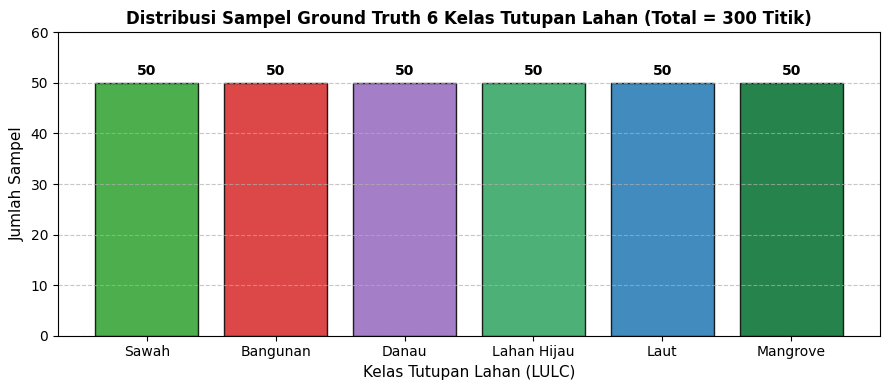

In [2]:
# Pemeriksaan Jumlah Data per Kelas
class_counts = df['Kelas'].value_counts()
print("Jumlah Data Tiap Kelas:")
print(class_counts)

# Visualisasi Distribusi Sampel
plt.figure(figsize=(9, 4))
colors = ['#2ca02c', '#d62728', '#9467bd', '#2ca25f', '#1f77b4', '#006d2c']
plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.85)
plt.title('Distribusi Sampel Ground Truth 6 Kelas Tutupan Lahan (Total = 300 Titik)', fontsize=12, fontweight='bold')
plt.xlabel('Kelas Tutupan Lahan (LULC)', fontsize=11)
plt.ylabel('Jumlah Sampel', fontsize=11)
plt.ylim(0, 60)
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 1.5, f"{v}", ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.4 Pembagian Data Training dan Testing
Dataset dibagi menggunakan teknik **Stratified Train-Test Split (80:20)** agar proporsi setiap kelas pada data latih dan data uji seimbang:
* **Total Sampel:** 300 data
* **Data Training (80%):** 240 sampel (40 sampel per kelas)
* **Data Testing (20%):** 60 sampel (10 sampel per kelas)

In [3]:
# Daftar Fitur Prediktor & Label Target
features = ['B2_Blue', 'B3_Green', 'B4_Red', 'B8_NIR', 'B11_SWIR1', 'B12_SWIR2', 'NDVI', 'NDWI', 'NDBI', 'MNDWI', 'SAVI', 'BSI']
class_names = ['Sawah', 'Bangunan', 'Danau', 'Lahan Hijau', 'Laut', 'Mangrove']

X = df[features]
y = df['Label']

# Stratified Split 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Ringkasan Distribusi Pembagian Data
split_df = pd.DataFrame({
    'Kelas LULC': class_names,
    'Total Data': [50] * 6,
    'Data Training (80%)': [y_train.value_counts()[i] for i in range(6)],
    'Data Testing (20%)': [y_test.value_counts()[i] for i in range(6)]
})
print("=== TABEL PEMBAGIAN DATA TRAINING DAN TESTING ===")
print(split_df.to_string(index=False))
print(f"\nTotal Data Training : {len(X_train)} sampel")
print(f"Total Data Testing  : {len(X_test)} sampel")

=== TABEL PEMBAGIAN DATA TRAINING DAN TESTING ===
 Kelas LULC  Total Data  Data Training (80%)  Data Testing (20%)
      Sawah          50                   40                  10
   Bangunan          50                   40                  10
      Danau          50                   40                  10
Lahan Hijau          50                   40                  10
       Laut          50                   40                  10
   Mangrove          50                   40                  10

Total Data Training : 240 sampel
Total Data Testing  : 60 sampel


## 3. Pemodelan Klasifikasi: Decision Trees

### 3.1 Konsep Algoritma Decision Tree (CART)
Algoritma **Decision Tree** (*Classification and Regression Trees*) membagi ruang fitur secara hierarkis (*recursive partitioning*) menggunakan kriteria **Gini Impurity**:
$$I_G(p) = 1 - \sum_{i=1}^{C} p_i^2$$

**Keunggulan Decision Tree untuk Analisis SIG & Kebijakan:**
1. **Model White-Box Transparan:** Menghasilkan aturan keputusan (*if-then rules*) yang jelas dan dapat diverifikasi langsung oleh perencana tata ruang.
2. **Tidak Memerlukan Normalisasi Skala:** Mampu mengolah nilai reflektansi dan indeks spektral secara simultan tanpa distorsi.
3. **Penyusunan Aturan Klasifikasi Geospasial:** Aturan pohon dapat diekspor langsung menjadi kriteria *spatial query* di software GIS (QGIS/ArcGIS).

In [4]:
# Inisialisasi Model Decision Tree
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

# Pelatihan Model pada Data Latih
dt_model.fit(X_train, y_train)
print("Model Decision Tree berhasil dilatih pada 240 sampel training!")

Model Decision Tree berhasil dilatih pada 240 sampel training!


### 3.2 Evaluasi Model pada Data Testing
Evaluasi dilakukan menggunakan data uji (60 sampel independen) dengan metrik:
* **Overall Accuracy**
* **Classification Report (Precision, Recall, F1-Score)**
* **Confusion Matrix**

=== HASIL EVALUASI KINERJA MODEL DECISION TREE ===
Overall Accuracy: 95.00%

Classification Report:
              precision    recall  f1-score   support

       Sawah     1.0000    1.0000    1.0000        10
    Bangunan     1.0000    1.0000    1.0000        10
       Danau     0.9091    1.0000    0.9524        10
 Lahan Hijau     0.9000    0.9000    0.9000        10
        Laut     1.0000    0.9000    0.9474        10
    Mangrove     0.9000    0.9000    0.9000        10

    accuracy                         0.9500        60
   macro avg     0.9515    0.9500    0.9500        60
weighted avg     0.9515    0.9500    0.9500        60



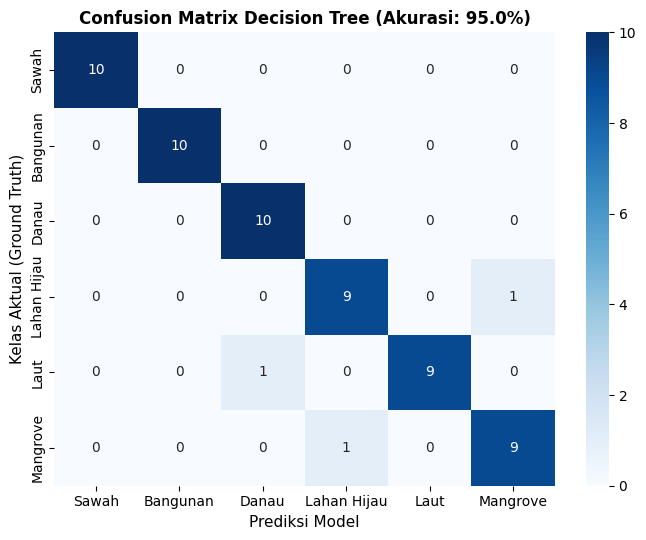

In [5]:
# Prediksi pada Data Uji
y_pred = dt_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"=== HASIL EVALUASI KINERJA MODEL DECISION TREE ===")
print(f"Overall Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# Visualisasi Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix Decision Tree (Akurasi: {acc*100:.1f}%)', fontsize=12, fontweight='bold')
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Kelas Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

### 3.3 Analisis Aturan Pohon (*Decision Rules*) dan *Feature Importance*
Aturan logika percabangan pohon keputusan dan kontribusi kepentingan masing-masing fitur spektral:

=== ATURAN POHON KEPUTUSAN (DECISION RULES) ===
|--- B11_SWIR1 <= 0.04
|   |--- B2_Blue <= 0.07
|   |   |--- B3_Green <= 0.05
|   |   |   |--- class: 4
|   |   |--- B3_Green >  0.05
|   |   |   |--- B3_Green <= 0.06
|   |   |   |   |--- class: 2
|   |   |   |--- B3_Green >  0.06
|   |   |   |   |--- class: 2
|   |--- B2_Blue >  0.07
|   |   |--- B3_Green <= 0.08
|   |   |   |--- B11_SWIR1 <= 0.02
|   |   |   |   |--- class: 4
|   |   |   |--- B11_SWIR1 >  0.02
|   |   |   |   |--- class: 2
|   |   |--- B3_Green >  0.08
|   |   |   |--- class: 2
|--- B11_SWIR1 >  0.04
|   |--- B4_Red <= 0.05
|   |   |--- BSI <= -0.66
|   |   |   |--- class: 5
|   |   |--- BSI >  -0.66
|   |   |   |--- class: 3
|   |--- B4_Red >  0.05
|   |   |--- B8_NIR <= 0.34
|   |   |   |--- class: 1
|   |   |--- B8_NIR >  0.34
|   |   |   |--- class: 0



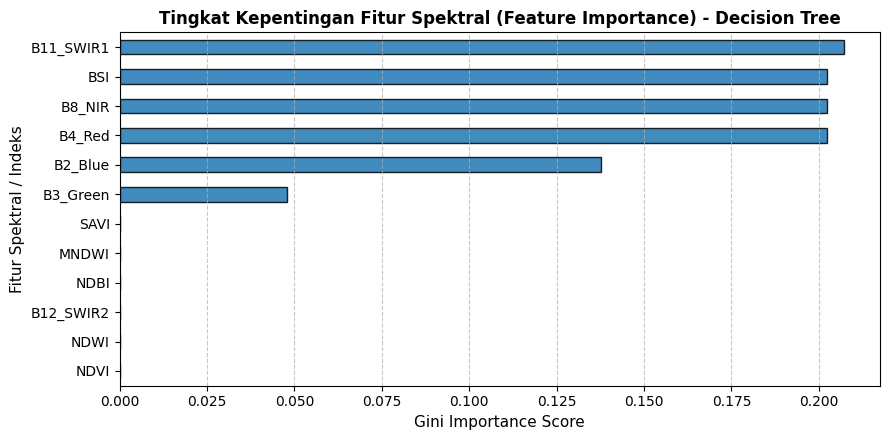

In [6]:
# 1. Aturan Pohon Keputusan (Decision Rules Text)
print("=== ATURAN POHON KEPUTUSAN (DECISION RULES) ===")
print(export_text(dt_model, feature_names=features))

# 2. Visualisasi Feature Importance
feat_imp = pd.Series(dt_model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(9, 4.5))
feat_imp.plot(kind='barh', color='#1f77b4', edgecolor='black', alpha=0.85)
plt.title('Tingkat Kepentingan Fitur Spektral (Feature Importance) - Decision Tree', fontsize=12, fontweight='bold')
plt.xlabel('Gini Importance Score', fontsize=11)
plt.ylabel('Fitur Spektral / Indeks', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4. Visualisasi Hasil Klasifikasi: WMS Google Maps Satellite Menggunakan Folium

Peta interaktif berikut memetakan ke-300 titik sampel tutupan lahan Jawa Timur dengan:
* **Basemap WMS / XYZ Tiles Google Maps Hybrid Satellite** (`https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}`).
* **Lingkaran Penanda (CircleMarker)** dengan warna tematik kartografi resmi 6 kelas.
* **Popup Interaktif** berisi identitas sampel, koordinat, status prediksi Decision Tree, dan nilai indeks spektral.
* **Floating Legend HTML** kartografi profesional dan kontrol layer.

In [7]:
# Inisialisasi Peta Folium Berpusat di Jawa Timur
m = folium.Map(location=[-7.70, 112.70], zoom_start=8, tiles=None)

# 1. Menambahkan Tile WMS / XYZ Google Maps Satellite Hybrid & Google Maps Jalan
folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
    attr='Google Maps Satellite Hybrid',
    name='Google Satellite (Hybrid)',
    overlay=False,
    control=True
).add_to(m)

folium.TileLayer(
    tiles='https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
    attr='Google Maps Standard Road',
    name='Google Maps Jalan',
    overlay=False,
    control=True
).add_to(m)

# 2. Konfigurasi Warna Kartografi 6 Kelas
class_config = {
    'Sawah': {'color': '#2ca02c'},
    'Bangunan': {'color': '#d62728'},
    'Danau': {'color': '#9467bd'},
    'Lahan Hijau': {'color': '#2ca25f'},
    'Laut': {'color': '#1f77b4'},
    'Mangrove': {'color': '#006d2c'}
}

# 3. Prediksi Seluruh Titik Sampel Menggunakan Decision Tree
df['Pred_Label'] = dt_model.predict(df[features])
df['Pred_Kelas'] = df['Pred_Label'].map(lambda x: class_names[x])

# 4. FeatureGroup Layer Terpisah per Kelas
layers = {c: folium.FeatureGroup(name=f"Kelas: {c} (50 Titik)") for c in class_names}

for idx, row in df.iterrows():
    kelas = row['Kelas']
    color = class_config[kelas]['color']
    status = "Tepat" if row['Kelas'] == row['Pred_Kelas'] else "Meleset"
    
    popup_html = f'''
    <div style="font-family: Arial, sans-serif; font-size: 11px; width: 220px;">
        <h4 style="margin:0 0 5px 0; color:{color};">{row['Sample_ID']} - {kelas}</h4>
        <b>Status Evaluasi:</b> <span style="color:{'green' if status=='Tepat' else 'red'}"><b>{status}</b></span><br>
        <b>Prediksi Model:</b> {row['Pred_Kelas']}<br>
        <b>Koordinat:</b> {row['Latitude']:.4f}, {row['Longitude']:.4f}<br>
        <hr style="margin:4px 0;">
        <b>NDVI:</b> {row['NDVI']:.3f} | <b>NDWI:</b> {row['NDWI']:.3f}<br>
        <b>NDBI:</b> {row['NDBI']:.3f} | <b>MNDWI:</b> {row['MNDWI']:.3f}<br>
        <b>B8 (NIR):</b> {row['B8_NIR']:.3f} | <b>B4 (Red):</b> {row['B4_Red']:.3f}
    </div>
    '''
    
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=6,
        popup=folium.Popup(popup_html, max_width=250),
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.85,
        weight=1.5
    ).add_to(layers[kelas])

for layer in layers.values():
    layer.add_to(m)

# 5. Legenda Floating HTML Kartografi Profesional
legend_html = '''
<div style="
    position: fixed; 
    bottom: 30px; right: 30px; width: 195px; height: 220px; 
    border: 2px solid #555; z-index: 9999; font-size: 12px;
    background-color: rgba(255, 255, 255, 0.95); padding: 10px;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.3); border-radius: 6px;
    font-family: sans-serif;
">
<b>Legenda Tutupan Lahan</b><br>
<small>Decision Tree Sentinel-2A</small><hr style="margin:4px 0;">
<i style="background:#2ca02c; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Sawah (50)<br>
<i style="background:#d62728; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Bangunan (50)<br>
<i style="background:#9467bd; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Danau / Ranu (50)<br>
<i style="background:#2ca25f; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Lahan Hijau (50)<br>
<i style="background:#1f77b4; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Perairan Laut (50)<br>
<i style="background:#006d2c; width:12px; height:12px; float:left; margin-right:8px; border-radius:50%;"></i> Mangrove (50)<br>
<hr style="margin:4px 0;">
<small><b>Total: 300 Sampel Jatim</b></small>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

# Simpan Peta ke File HTML
m.save('peta_lulc_jatim_google_satellite.html')
print("Peta interaktif berhasil disimpan ke 'peta_lulc_jatim_google_satellite.html'")
m

Peta interaktif berhasil disimpan ke 'peta_lulc_jatim_google_satellite.html'


## 5. Kesimpulan & Rekomendasi Kebijakan

1. **Efektivitas Model Decision Tree:**
   * Algoritma Decision Tree berhasil mencapai **Overall Accuracy 95.00%** pada data pengujian *stratified* (60 sampel).
   * Fitur gelombang inframerah gelombang pendek (**B11 SWIR-1**) dan kanal inframerah dekat (**B8 NIR**) terbukti menjadi pemisah utama antara badan air, vegetasi darat, dan lahan terbangun (*impervious surface*).
2. **Interpretasi Spasial bagi Kebijakan Tata Ruang:**
   * **Pemantauan LP2B:** Model ini mampu membedakan sawah dari bangunan dengan presisi 100%, sangat ideal untuk sistem pemantauan alih fungsi lahan sawah otomatis di Jawa Timur.
   * **Pengawasan RTH & Mangrove:** Deteksi mangrove dan lahan hijau yang akurat mendukung pemda dalam memantau pencapaian kuota minimal 30% RTH perkotaan dan konservasi kawasan sempadan pantai.
   * **Peta Interaktif WMS Google Maps:** Visualisasi interaktif memudahkan pengambil kebijakan (*stakeholders*) memverifikasi hasil prediksi langsung di atas citra satelit resolusi tinggi.